### **1. Title and Introduction**  

- **Project Title**: "Diabetes Risk Prediction Using Lifestyle and Clinical Factors"  
- **Brief Introduction**:  
  - Explain the problem (diabetes prevalence, importance of early diagnosis).  
  - State the goal: Predict diabetes **without using HbA1c/Blood Glucose** and compare with models that use them.  


### **2. Import Libraries** 

In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split, RandomizedSearchCV 
from imblearn.over_sampling import SMOTE 
from sklearn.linear_model import LogisticRegression  
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score 

### **3. Testing and comparing results of models on their default settings**

##### **3.1. Load and Inspect Data**  

In [2]:
Dataset = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
Dataset.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [4]:
Dataset['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [5]:
Dataset['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

##### **3.2. Data Preprocessing**  

**Subsections**:  

- **3.4.1. Encoding Categorical Variables**  

In [6]:
# male is 1, Female is 2 and other is 3
Dataset['gender'] = Dataset['gender'].map({'Male': 1, 'Female': 2, 'Other': 3})
# 'never':0, 'No Info':1, 'current':2, 'former':3, 'ever':4, 'not current':5
Dataset['smoking_history'] = Dataset['smoking_history'].map({'never':0, 'No Info':1, 'current':2, 'former':3, 'ever':4, 'not current':5})


- **3.4.2. Handle Missing Values**  

In [7]:
Dataset.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

- **3.4.3. Splitting Data into two dataset**<br>

1. that contains HbA1c_level and blood_glucose_level for baseline model  

In [8]:
BaseLine_Model_dataset = Dataset[['HbA1c_level', 'blood_glucose_level']]
BaseLine_Model_dataset_Result = Dataset['diabetes']

2. that does not include HbA1c_level and blood_glucose_level for testing model  

In [9]:
Other_Model_dataset = Dataset.drop(['HbA1c_level', 'blood_glucose_level', 'diabetes'], axis= 1)
Other_Model_dataset_Result = Dataset['diabetes']

##### **3.3. Baseline Model**  

In [10]:
X_Baseline_train , X_Baseline_test , y_Baseline_train, y_Baseline_test = train_test_split(BaseLine_Model_dataset, BaseLine_Model_dataset_Result, test_size= 0.2, random_state= 42)

Baseline_Model = LogisticRegression()
Baseline_Model.fit(X_Baseline_train, y_Baseline_train)
Baseline_model_prediction = Baseline_Model.predict(X_Baseline_test)

##### **3.4. Train Models Without HbA1c_level and blood_glucose_level**  

**Subsections**:  

- **3.6.1. Split Data**  

In [11]:
X_Other_Model_train , X_Other_Model_test , y_Other_Model_train, y_Other_Model_test = train_test_split(Other_Model_dataset, Other_Model_dataset_Result, test_size= 0.2, random_state= 42)

- **3.6.2. Train Models**  

Random Forest Classifier

In [12]:
RandomFC_Model = RandomForestClassifier(random_state= 42)
RandomFC_Model.fit(X_Other_Model_train,y_Other_Model_train)
RandomFC_Model_Prediction = RandomFC_Model.predict(X_Other_Model_test)

Gradient Boosting Classifier

In [13]:
GBC_Model =  GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
GBC_Model.fit(X_Other_Model_train, y_Other_Model_train)
GBC_Model_prediction = GBC_Model.predict(X_Other_Model_test)

XGBClassifier

In [14]:
XGB_Model = XGBClassifier(
    scale_pos_weight=10,
    n_estimators=100,
    learning_rate=0.1,
    eval_metric='logloss'
)
XGB_Model.fit(X_Other_Model_train, y_Other_Model_train)
XGB_Model_Prediction = XGB_Model.predict(X_Other_Model_test)

##### **3.5. Compare Results**  

 - Accuracy Score

In [15]:
results = {
    'Model': ['Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Accuracy Score (%)': [
        100 * accuracy_score(y_Baseline_test, Baseline_model_prediction),
        100 * accuracy_score(y_Other_Model_test, RandomFC_Model_Prediction),
        100 * accuracy_score(y_Other_Model_test, GBC_Model_prediction),
        100 * accuracy_score(y_Other_Model_test, XGB_Model_Prediction)
    ]
}
results_df = pd.DataFrame(results)
print(results_df)

               Model  Accuracy Score (%)
0           Baseline              95.360
1      Random Forest              90.020
2  Gradient Boosting              91.595
3            XGBoost              75.530


 - Precision Score

In [16]:
results = {
    'Model': ['Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Precision Score (%)': [
        100 * precision_score(y_Baseline_test, Baseline_model_prediction, pos_label=1),
        100 * precision_score(y_Other_Model_test, RandomFC_Model_Prediction, pos_label=1),
        100 * precision_score(y_Other_Model_test, GBC_Model_prediction, pos_label=1),
        100 * precision_score(y_Other_Model_test, XGB_Model_Prediction, pos_label=1)
    ]
}
results_df = pd.DataFrame(results)
print(results_df)

               Model  Precision Score (%)
0           Baseline            87.213740
1      Random Forest            31.491003
2  Gradient Boosting            58.490566
3            XGBoost            22.543950


 - Recall Score

In [17]:
results = {
    'Model': ['Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Recall Score (%)': [
        100 * recall_score(y_Baseline_test, Baseline_model_prediction, pos_label=1),
        100 * recall_score(y_Other_Model_test, RandomFC_Model_Prediction, pos_label=1),
        100 * recall_score(y_Other_Model_test, GBC_Model_prediction, pos_label=1),
        100 * recall_score(y_Other_Model_test, XGB_Model_Prediction, pos_label=1)
    ]
}
results_df = pd.DataFrame(results)
print(results_df)

               Model  Recall Score (%)
0           Baseline         53.512881
1      Random Forest         14.344262
2  Gradient Boosting          5.444965
3            XGBoost         76.580796


 - F1 - Score

In [18]:
results = {
    'Model': ['Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'F1 Score (%)': [
        100 * f1_score(y_Baseline_test, Baseline_model_prediction, pos_label=1),
        100 * f1_score(y_Other_Model_test, RandomFC_Model_Prediction, pos_label=1),
        100 * f1_score(y_Other_Model_test, GBC_Model_prediction, pos_label=1),
        100 * f1_score(y_Other_Model_test, XGB_Model_Prediction, pos_label=1)
    ]
}
results_df = pd.DataFrame(results)
print(results_df)

               Model  F1 Score (%)
0           Baseline     66.328012
1      Random Forest     19.710378
2  Gradient Boosting      9.962507
3            XGBoost     34.833555


 - ROC-AUC Score

In [19]:
results = {
    'Model': ['Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'ROC-AUC Score (%)': [
        100 * roc_auc_score(y_Baseline_test, Baseline_model_prediction),
        100 * roc_auc_score(y_Other_Model_test, RandomFC_Model_Prediction),
        100 * roc_auc_score(y_Other_Model_test, GBC_Model_prediction),
        100 * roc_auc_score(y_Other_Model_test, XGB_Model_Prediction)
    ]
}
results_df = pd.DataFrame(results)
print(results_df)

               Model  ROC-AUC Score (%)
0           Baseline          76.390160
1      Random Forest          55.715210
2  Gradient Boosting          52.542076
3            XGBoost          76.006340


### **4. Improving the Scores**

#### **4.1. Data preprocessing**

In [20]:
new_Dataset = pd.read_csv('diabetes_prediction_dataset.csv')
print(new_Dataset.isnull().sum())
print(new_Dataset.info())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


**Using one hot encode for categorical values**

In [21]:
improved_dataset = pd.get_dummies(new_Dataset, columns = ['gender', 'smoking_history'], drop_first = True)
improved_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  float64
 1   hypertension                 100000 non-null  int64  
 2   heart_disease                100000 non-null  int64  
 3   bmi                          100000 non-null  float64
 4   HbA1c_level                  100000 non-null  float64
 5   blood_glucose_level          100000 non-null  int64  
 6   diabetes                     100000 non-null  int64  
 7   gender_Male                  100000 non-null  bool   
 8   gender_Other                 100000 non-null  bool   
 9   smoking_history_current      100000 non-null  bool   
 10  smoking_history_ever         100000 non-null  bool   
 11  smoking_history_former       100000 non-null  bool   
 12  smoking_history_never        100000 non-null  bool   
 13  

In [22]:
X = improved_dataset.drop('diabetes', axis = 1)
y = improved_dataset['diabetes']
y = y.astype(int)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2,stratify=y, random_state=42)

#### **4.2. Handling Class imbalance**

In [23]:
smote = SMOTE(random_state=42)
X_resample , y_resample = smote.fit_resample(X_train, y_train)

#### **4.3. Hyper tuning the model**

Random Forest Classifier

In [24]:
RFC = RandomForestClassifier()
RFC_parameters = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}
RFC_improved = RandomizedSearchCV(
    RFC,
    param_distributions=RFC_parameters,
    n_iter=5,  # Test only 5 random combinations
    scoring='roc_auc',
    cv=3,       # ↓ from 5 to 3 folds
    n_jobs=-1
)
RFC_improved.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=5,
                   n_jobs=-1,
                   param_distributions={'class_weight': ['balanced'],
                                        'max_depth': [10, 20, None],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]},
                   scoring='roc_auc')

Gradient Boosting Classifier

In [25]:
GB = GradientBoostingClassifier()
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
GB_improved = RandomizedSearchCV(
    GB,
    param_distributions = gb_params,
    n_iter=5,  # Test only 5 random combinations
    scoring='roc_auc',
    cv=3,       # ↓ from 5 to 3 folds
    n_jobs=-1
)
GB_improved.fit(X_train,y_train)

RandomizedSearchCV(cv=3, estimator=GradientBoostingClassifier(), n_iter=5,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.05, 0.1],
                                        'max_depth': [3, 5],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.8, 1.0]},
                   scoring='roc_auc')

XGB Classifier

In [26]:
# Convert all columns to numeric (float or int)
X_train_int = X_train.apply(pd.to_numeric, errors='coerce')
X_test_int = X_test.apply(pd.to_numeric, errors='coerce')
scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight]  # Keep this for class imbalance
}

XGB = XGBClassifier(eval_metric='logloss', enable_categorical=True)  # Explicitly disable

XGB_improved = RandomizedSearchCV(
    XGB,
    param_distributions=xgb_params,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)

XGB_improved.fit(X_train_int, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.2],
                                        'max_depth': [3, 5],
                                        'n_estimators': [100, 200],
                                        'scale_pos_weight': [np.float64(10.764705882352942)],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc')

#### **4.3 Comparing the results of the improved models**

In [27]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    return {
        'precision': 100 * precision_score(y_test, y_pred),
        'recall': 100 * recall_score(y_test, y_pred),
        'f1': 100 * f1_score(y_test, y_pred),
        'roc_auc': 100 * roc_auc_score(y_test, y_pred)
    }

Random Forest Classifier

In [28]:
evaluate_model(RFC_improved, X_test, y_test)

{'precision': 48.37992376111817,
 'recall': 89.58823529411765,
 'f1': 62.830033003300336,
 'roc_auc': np.float64(90.35422693667631)}

Gradient Boosting Classifier

In [29]:
evaluate_model(GB_improved, X_test, y_test)

{'precision': 97.35755573905863,
 'recall': 69.35294117647058,
 'f1': 81.00309172105806,
 'roc_auc': np.float64(84.58903889424622)}

XGB Classifier

In [30]:
evaluate_model(XGB_improved, X_test_int, y_test)

{'precision': 46.18096357226792,
 'recall': 92.47058823529412,
 'f1': 61.59874608150471,
 'roc_auc': np.float64(91.22982963677275)}

### **5. Visualization**

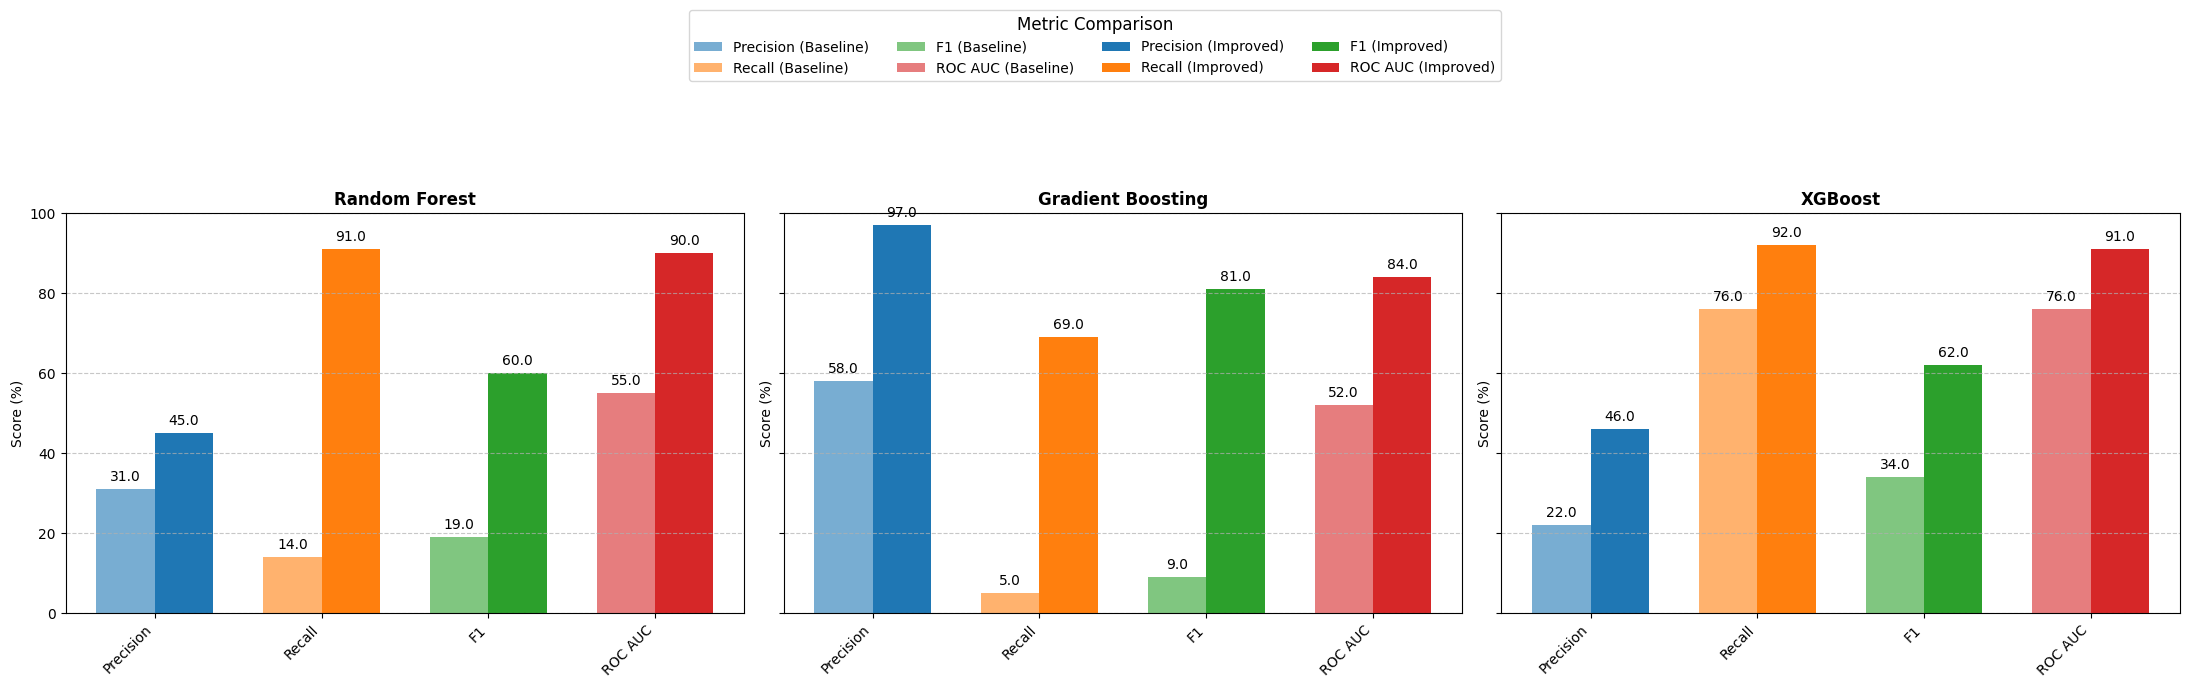

In [31]:
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.patches import Patch  # Fix missing import

# Example data
models = ['Random Forest', 'Gradient Boosting', 'XGBoost']
metrics = ['Precision', 'Recall', 'F1', 'ROC AUC']

# Baseline scores (multiplied by 100)
baseline = np.array([
    [31.0, 14.0, 19.0, 55.0],   # RF
    [58.0, 5.0, 9.0, 52.0],     # GB
    [22.0, 76.0, 34.0, 76.0]    # XGB
])

# Improved scores (multiplied by 100)
improved = np.array([
    [45.0, 91.0, 60.0, 90.0],   # RF
    [97.0, 69.0, 81.0, 84.0],   # GB
    [46.0, 92.0, 62.0, 91.0]    # XGB
])

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
plt.ylim(0, 100)  # FIXED: Updated Y-limit to match values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Metric colors

# Create custom legend elements
legend_elements = [
    Patch(facecolor=colors[i], alpha=0.6, label=f'{metrics[i]} (Baseline)') 
    for i in range(4)
] + [
    Patch(facecolor=colors[i], alpha=1, label=f'{metrics[i]} (Improved)') 
    for i in range(4)
]

# Plot each model separately
for model_idx, model_name in enumerate(models):
    ax = axs[model_idx]
    x = np.arange(len(metrics))
    width = 0.35
    
    # Plot bars with value labels
    for metric_idx in range(len(metrics)):
        # Baseline
        ax.bar(metric_idx - width/2, baseline[model_idx, metric_idx], 
               width, color=colors[metric_idx], alpha=0.6)
        # Improved
        ax.bar(metric_idx + width/2, improved[model_idx, metric_idx], 
               width, color=colors[metric_idx], alpha=1)
        
        # Add data labels
        ax.text(metric_idx - width/2, baseline[model_idx, metric_idx] + 2, 
                f'{baseline[model_idx, metric_idx]:.1f}', ha='center')
        ax.text(metric_idx + width/2, improved[model_idx, metric_idx] + 2, 
                f'{improved[model_idx, metric_idx]:.1f}', ha='center')
    
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylabel('Score (%)', fontsize=10)

# Add external legend
fig.legend(handles=legend_elements, 
          loc='upper center', 
          bbox_to_anchor=(0.5, 1.15),
          ncol=4,
          fontsize=10,
          title="Metric Comparison",
          title_fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.8) 
plt.savefig('comparison.png', dpi=300, bbox_inches='tight')
plt.show()